<a href="https://colab.research.google.com/github/yoolmalaak/concrete-crack-and-fracture-analysis/blob/main/notebooks/06_fracture_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fracture Data Analysis

This notebook analyses the ConcreteTBF three-point bending fracture dataset using statistical analysis and machine-learning methods. The analysis focuses on the relationships between concrete specimen geometry, material properties, and fracture behaviour, with particular emphasis on the reported fracture energy parameter.

## 1. Environment Setup

This section defines the project path and imports the libraries required for fracture-data analysis.

In [1]:
!git clone https://github.com/yoolmalaak/concrete-crack-and-fracture-analysis.git /content/concrete-crack-and-fracture-analysis-repo

Cloning into '/content/concrete-crack-and-fracture-analysis-repo'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 141 (delta 46), reused 96 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 39.08 MiB | 9.15 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/concrete-crack-and-fracture-analysis")
FRACTURE_DATA_PATH = Path("/content/fracture_data.xlsx")

print("Project root:", PROJECT_ROOT)
print("Fracture data:", FRACTURE_DATA_PATH)
print("File exists:", FRACTURE_DATA_PATH.exists())

Project root: /content/concrete-crack-and-fracture-analysis
Fracture data: /content/fracture_data.xlsx
File exists: True


## 2. Load ConcreteTBF Dataset

This section loads the ConcreteTBF Excel dataset and inspects its workbook structure before selecting the data table for analysis.

In [4]:
excel_file = pd.ExcelFile(FRACTURE_DATA_PATH)

print("Available sheets:")
for sheet in excel_file.sheet_names:
    print("-", sheet)

Available sheets:
- Sheet1


### 2.1 Load Fracture Data

The ConcreteTBF fracture dataset is loaded from the `Sheet1` worksheet of the Excel file.

In [5]:
fracture_df = pd.read_excel(
    FRACTURE_DATA_PATH,
    sheet_name="Sheet1"
)

print("Dataset shape:", fracture_df.shape)
print("\nColumns:")
print(fracture_df.columns.tolist())

fracture_df.head()

Dataset shape: (330, 8)

Columns:
['d (mm)', 'S (mm)', 'bw (mm)', 'a0 (mm)', 'Gc (N/mm)', 'ft (MPa)', 'E (GPa)', 'Pult (kN)']


,d (mm),S (mm),bw (mm),a0 (mm),Gc (N/mm),ft (MPa),E (GPa),Pult (kN)
0,250,800,100,125,0.070000,3.350000,27.203200,5.543000
1,360,900,250,160,0.073000,3.380000,27.324751,29.448743
2,310,1200,190,110,0.054000,3.660000,28.434029,15.215605
3,290,1000,170,120,0.069100,4.130000,30.204586,14.206183
4,280,700,200,85,0.060767,3.406667,27.432329,27.798306


### 2.2 Basic Dataset Inspection

The structure and contents of the ConcreteTBF dataset are examined to verify the number of observations, data types, missing values, and duplicate records before further analysis.

In [6]:
print("Dataset shape:", fracture_df.shape)

print("\nData types:")
print(fracture_df.dtypes)

print("\nMissing values:")
print(fracture_df.isna().sum())

print("\nDuplicate rows:", fracture_df.duplicated().sum())

Dataset shape: (330, 8)

Data types:
d (mm)         int64
S (mm)         int64
bw (mm)        int64
a0 (mm)        int64
Gc (N/mm)    float64
ft (MPa)     float64
E (GPa)      float64
Pult (kN)    float64
dtype: object

Missing values:
d (mm)       0
S (mm)       0
bw (mm)      0
a0 (mm)      0
Gc (N/mm)    0
ft (MPa)     0
E (GPa)      0
Pult (kN)    0
dtype: int64

Duplicate rows: 0


## 3. Data Inspection and Quality Checks

This section examines the numerical characteristics and ranges of the variables in the ConcreteTBF dataset to identify potential inconsistencies and establish the basis for subsequent exploratory analysis.

### 3.1 Descriptive Statistics

Descriptive statistics are calculated for the geometric, material, and fracture-related variables.

In [7]:
fracture_df.describe().T

,count,mean,std,min,25%,50%,75%,max
d (mm),330.0,214.909091,88.828021,50.000,150.000000,200.000000,300.000000,400.000000
S (mm),330.0,746.878788,315.443602,125.000,525.000000,750.000000,1000.000000,1300.000000
bw (mm),330.0,124.893939,60.051176,30.000,80.000000,110.000000,170.000000,250.000000
a0 (mm),330.0,68.187879,43.706202,4.000,31.250000,60.000000,98.750000,180.000000
Gc (N/mm),330.0,0.066410,0.027777,0.010,0.042600,0.065000,0.085000,0.141000
ft (MPa),330.0,3.550333,0.825348,1.800,3.000000,3.550000,4.285000,6.000000
E (GPa),330.0,28.265263,3.878233,19.000,25.785723,28.101906,30.882609,37.000000
Pult (kN),330.0,10.912512,8.053129,0.447,4.395490,8.605555,15.644877,32.335983


### 3.2 Variable Distributions

The distributions of the geometric, material, and fracture-related variables are visualized using histograms to identify their spread, concentration, and potential skewness.

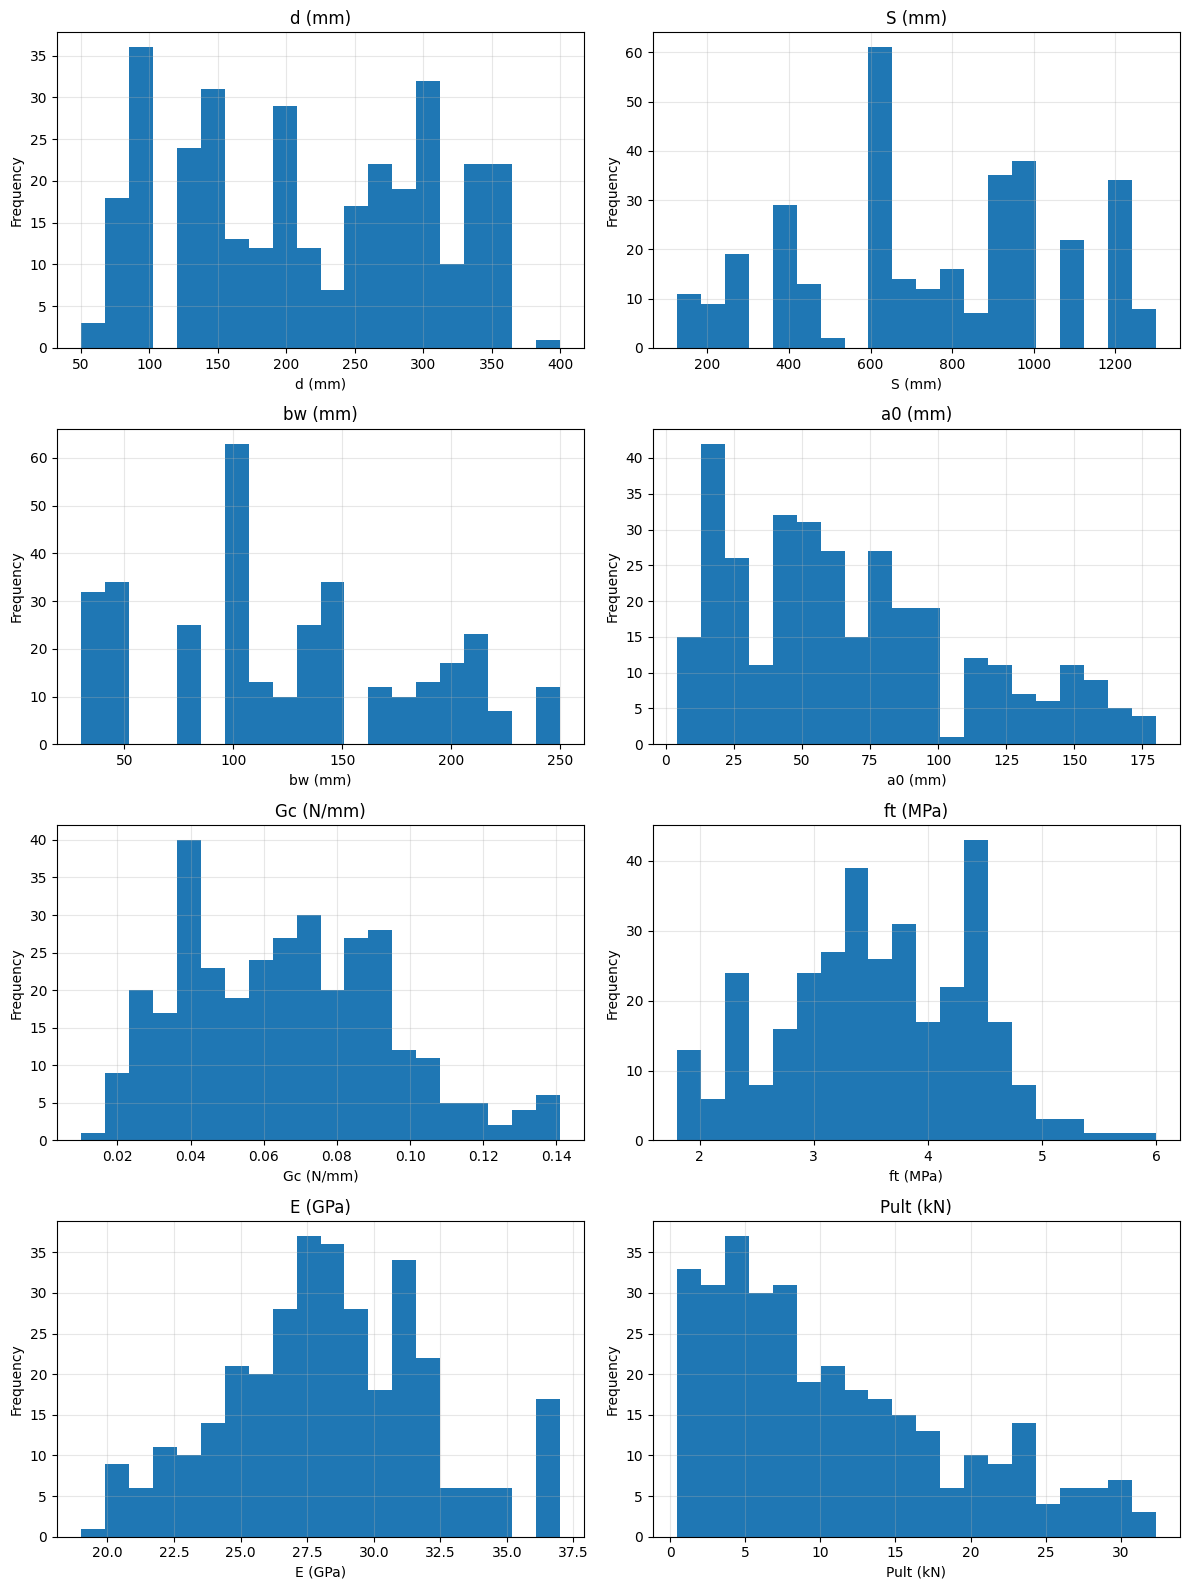

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for ax, column in zip(axes.flatten(), fracture_df.columns):
    ax.hist(fracture_df[column], bins=20)
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Boxplots

Boxplots are used to examine the spread of the variables and identify observations that may warrant further investigation as potential extreme values.

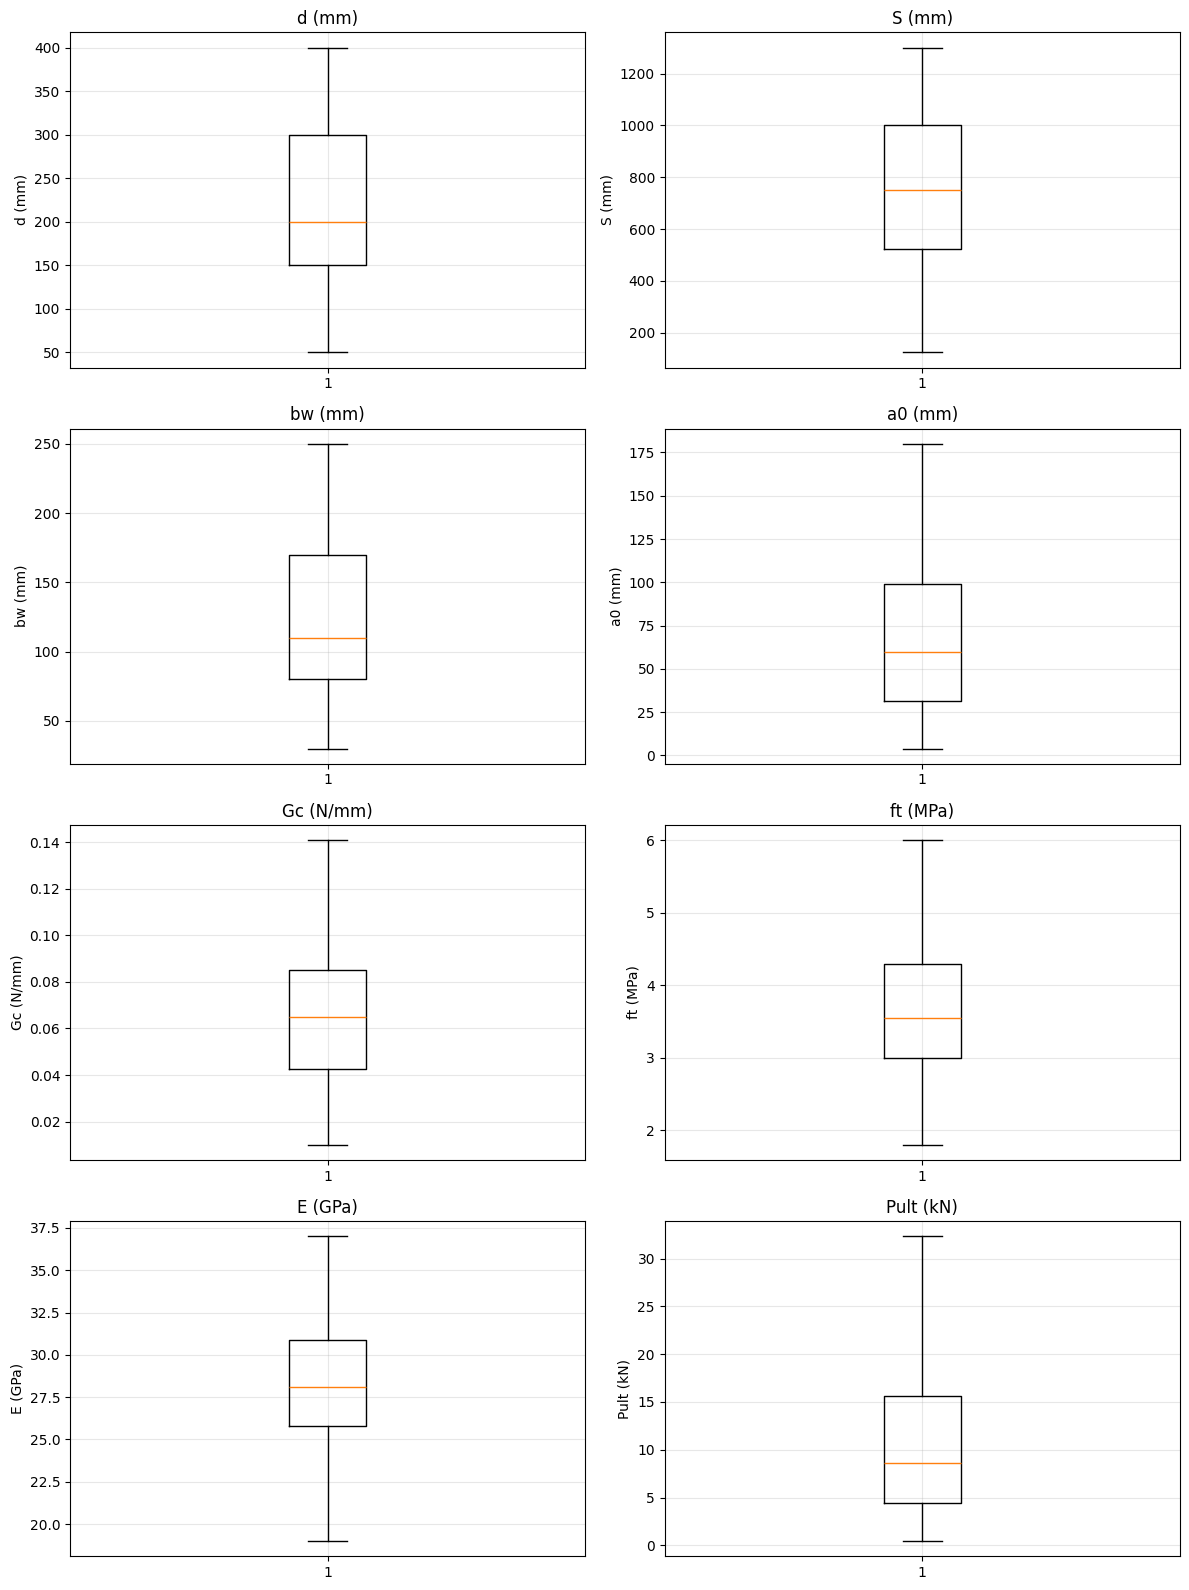

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for ax, column in zip(axes.flatten(), fracture_df.columns):
    ax.boxplot(fracture_df[column])
    ax.set_title(column)
    ax.set_ylabel(column)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Range and Physical Consistency Check

The numerical ranges of the variables are examined to identify any non-positive values that may indicate data-entry or measurement inconsistencies. In addition, the ratio of initial notch depth to beam depth (`a0/d`) is calculated to assess the relative size of the notch within the beam specimens. This provides an additional geometric consistency check before proceeding to exploratory analysis.

In [10]:
print("Minimum values:")
print(fracture_df.min())

print("\nNumber of non-positive values:")
print((fracture_df <= 0).sum())

Minimum values:
d (mm)        50.000
S (mm)       125.000
bw (mm)       30.000
a0 (mm)        4.000
Gc (N/mm)      0.010
ft (MPa)       1.800
E (GPa)       19.000
Pult (kN)      0.447
dtype: float64

Number of non-positive values:
d (mm)       0
S (mm)       0
bw (mm)      0
a0 (mm)      0
Gc (N/mm)    0
ft (MPa)     0
E (GPa)      0
Pult (kN)    0
dtype: int64


In [11]:
print("\nNotch-to-depth ratio summary:")

notch_ratio = fracture_df["a0 (mm)"] / fracture_df["d (mm)"]

print(notch_ratio.describe())
print("\nMaximum a0/d ratio:", notch_ratio.max())


Notch-to-depth ratio summary:
count    330.000000
mean       0.312789
std        0.140837
min        0.026316
25%        0.200000
50%        0.304563
75%        0.427198
max        0.666667
dtype: float64

Maximum a0/d ratio: 0.6666666666666666


## 4. Exploratory Data Analysis

This section explores the distributions and relationships among the geometric, material, and fracture-related variables in the ConcreteTBF dataset. Particular attention is given to fracture energy (`Gc`), which is used as the primary reported fracture-response parameter in the analysis.

### 4.1 Fracture Energy Distribution

The distribution of fracture energy (`Gc`) is examined to characterize its central tendency, variability, and overall spread within the ConcreteTBF dataset.

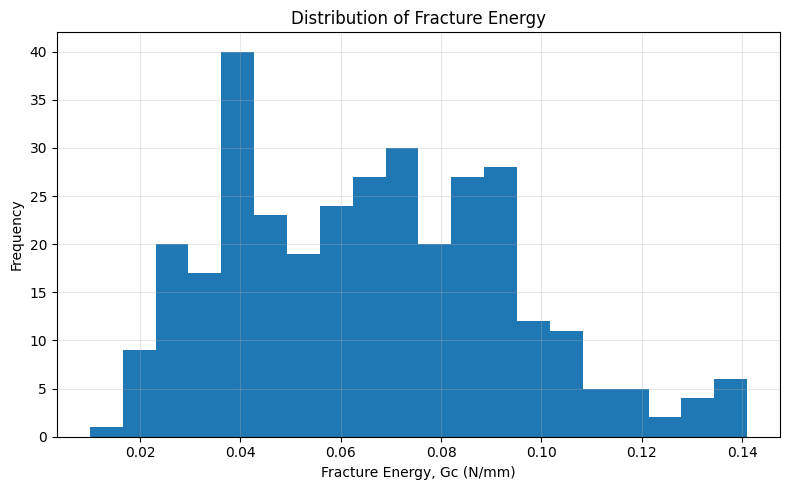

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    fracture_df["Gc (N/mm)"],
    bins=20
)

plt.xlabel("Fracture Energy, Gc (N/mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Fracture Energy")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Fracture Energy Summary

Key descriptive statistics for fracture energy (`Gc`) are calculated to quantify its central tendency and variability.

In [13]:
gc_summary = fracture_df["Gc (N/mm)"].describe()

print(gc_summary)

count    330.000000
mean       0.066410
std        0.027777
min        0.010000
25%        0.042600
50%        0.065000
75%        0.085000
max        0.141000
Name: Gc (N/mm), dtype: float64


### 4.3 Fracture Energy and Predictor Relationships

Scatter plots are used to visually examine the relationships between fracture energy (`Gc`) and the geometric, material, and ultimate-load variables before conducting correlation analysis.

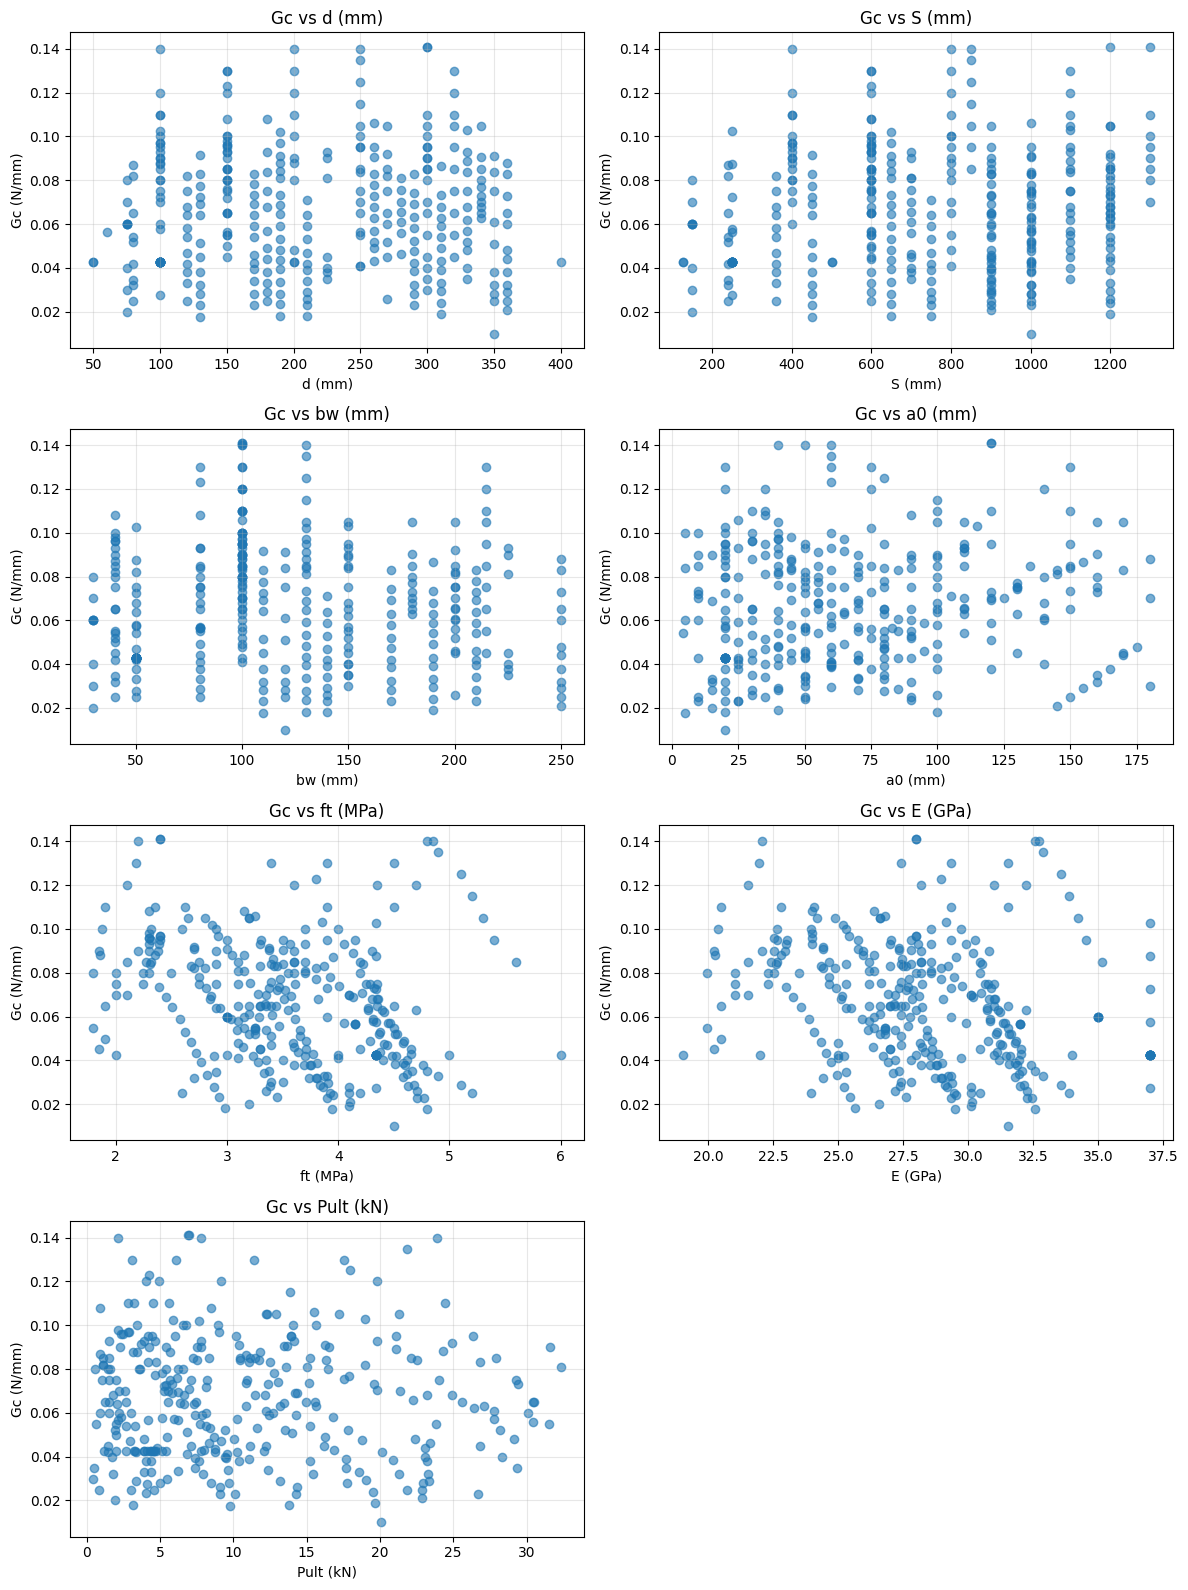

In [14]:
predictors = [
    "d (mm)",
    "S (mm)",
    "bw (mm)",
    "a0 (mm)",
    "ft (MPa)",
    "E (GPa)",
    "Pult (kN)"
]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for ax, column in zip(axes.flatten(), predictors):
    ax.scatter(
        fracture_df[column],
        fracture_df["Gc (N/mm)"],
        alpha=0.6
    )
    ax.set_xlabel(column)
    ax.set_ylabel("Gc (N/mm)")
    ax.set_title(f"Gc vs {column}")
    ax.grid(alpha=0.3)

axes.flatten()[-1].axis("off")

plt.tight_layout()
plt.show()

### 4.4 Correlation Analysis

Pearson correlation coefficients are calculated to quantify the linear relationships among the geometric, material, and fracture-related variables. The correlation analysis is used as an exploratory measure and does not imply causation.

In [15]:
correlation_matrix = fracture_df.corr(numeric_only=True)

correlation_matrix

,d (mm),S (mm),bw (mm),a0 (mm),Gc (N/mm),ft (MPa),E (GPa),Pult (kN)
d (mm),1.000000,0.898027,0.696168,0.701397,0.012684,0.172162,0.038334,0.784794
S (mm),0.898027,1.000000,0.677179,0.584126,0.110384,0.063085,-0.085701,0.636230
bw (mm),0.696168,0.677179,1.000000,0.564492,-0.054029,0.149131,0.002863,0.747977
a0 (mm),0.701397,0.584126,0.564492,1.000000,0.115467,0.037837,-0.038277,0.318508
Gc (N/mm),0.012684,0.110384,-0.054029,0.115467,1.000000,-0.283417,-0.256698,-0.036221
ft (MPa),0.172162,0.063085,0.149131,0.037837,-0.283417,1.000000,0.827978,0.318120
E (GPa),0.038334,-0.085701,0.002863,-0.038277,-0.256698,0.827978,1.000000,0.183831
Pult (kN),0.784794,0.636230,0.747977,0.318508,-0.036221,0.318120,0.183831,1.000000


### 4.5 Correlation Heatmap

A correlation heatmap is used to visualize the strength and direction of the linear relationships among the variables in the ConcreteTBF dataset.

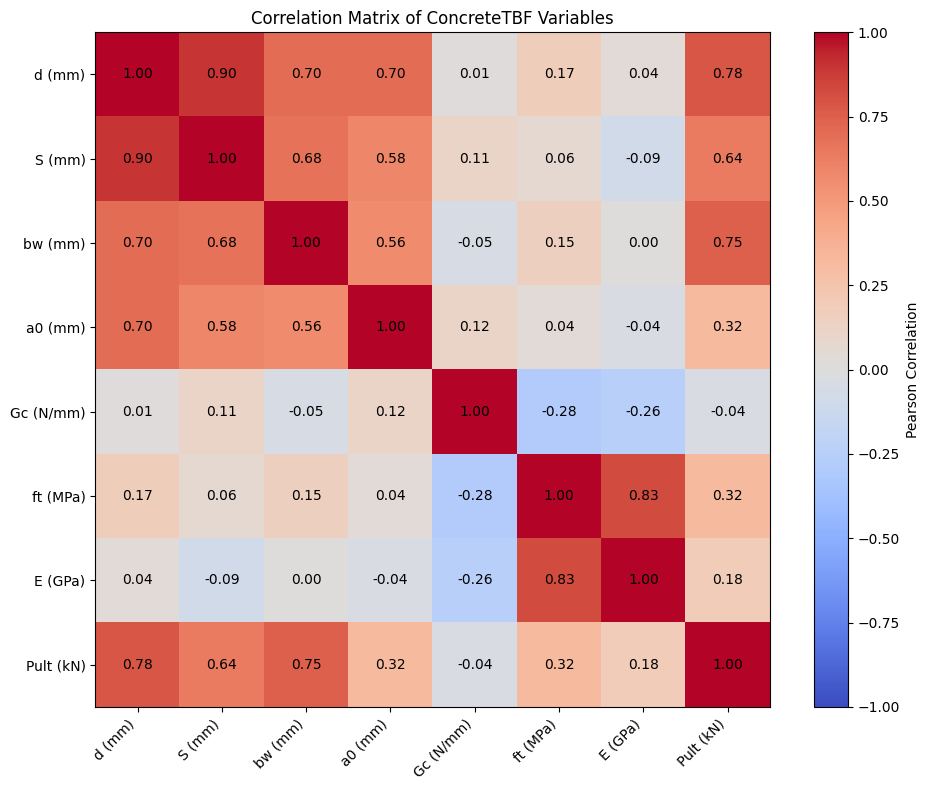

In [16]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of ConcreteTBF Variables")
plt.tight_layout()
plt.show()

The correlation heatmap confirms that fracture energy (`Gc`) has relatively weak linear correlations with the other variables. The strongest associations with `Gc` are negative relationships with tensile strength (`ft`, r = -0.28) and elastic modulus (`E`, r = -0.26), while the correlations with the geometric variables and ultimate load are weak.

In contrast, several strong positive correlations are observed among the predictor variables. Beam depth (`d`) is strongly correlated with span length (`S`, r = 0.90), while tensile strength (`ft`) is strongly correlated with elastic modulus (`E`, r = 0.83). Beam depth is also strongly associated with ultimate load (`Pult`, r = 0.78), and beam width (`bw`) has a strong correlation with ultimate load (r = 0.75). These relationships indicate that some predictors contain overlapping information, which will be considered when preparing the data for machine-learning analysis.

## 5. Fracture-Toughness Assessment

The ConcreteTBF dataset reports fracture energy (`Gc`) as one of its fracture-related variables. Since the present study focuses on fracture behaviour and considers fracture toughness as an important concept, the available variables were examined to determine whether a fracture-toughness parameter could be derived reliably from the dataset.

Fracture energy and fracture toughness are related fracture-mechanics parameters but are not interchangeable. A conversion between them requires an appropriate theoretical relationship together with the assumptions and material parameters required by that relationship. Therefore, `Gc` is retained as the reported fracture-energy parameter rather than being directly relabelled as fracture toughness.

### 5.2 Assessment of Available Parameters

The ConcreteTBF dataset contains beam geometry (`d`, `S`, `bw`, and `a0`), fracture energy (`Gc`), tensile strength (`ft`), elastic modulus (`E`), and ultimate load (`Pult`). Although these variables provide substantial information for analysing fracture behaviour, the available dataset documentation does not provide sufficient methodological information to establish a defensible conversion of the reported `Gc` values into a fracture-toughness parameter for the present study.

Consequently, no derived `KIC` values are introduced into the machine-learning analysis. The reported fracture energy (`Gc`) is retained as the primary fracture-response variable. This preserves the original terminology of the dataset and avoids introducing additional assumptions that cannot be adequately verified from the available data.

### 5.3 Implication for the Machine-Learning Analysis

Based on the fracture-toughness assessment, the machine-learning component focuses on predicting the reported fracture energy (`Gc`). The predictor variables are selected from the available geometric and material properties of the ConcreteTBF dataset. The resulting models are therefore interpreted as models of fracture-energy behaviour rather than direct models of fracture toughness (`KIC`).

## 6. Feature Preparation

This section defines the predictor variables and target variable for the machine-learning regression analysis. Fracture energy (`Gc`) is selected as the primary target because it is the reported fracture-response parameter in the ConcreteTBF dataset. The predictor variables comprise specimen geometry and material properties that are available independently of the reported fracture-energy response.

### 6.1 Define Predictors and Target

The geometric variables (`d`, `S`, `bw`, and `a0`) and material properties (`ft` and `E`) are selected as predictors of fracture energy (`Gc`). Ultimate load (`Pult`) is retained in the dataset for analysis but is not included as a primary predictor because it represents a test response rather than an independent geometric or material input.

In [17]:
predictor_columns = [
    "d (mm)",
    "S (mm)",
    "bw (mm)",
    "a0 (mm)",
    "ft (MPa)",
    "E (GPa)"
]

target_column = "Gc (N/mm)"

X = fracture_df[predictor_columns].copy()
y = fracture_df[target_column].copy()

print("Predictors:")
print(X.columns.tolist())

print("\nTarget:")
print(target_column)

print("\nPredictor shape:", X.shape)
print("Target shape:", y.shape)

Predictors:
['d (mm)', 'S (mm)', 'bw (mm)', 'a0 (mm)', 'ft (MPa)', 'E (GPa)']

Target:
Gc (N/mm)

Predictor shape: (330, 6)
Target shape: (330,)


### 6.2 Check Prepared Data

The prepared predictor and target datasets are inspected to confirm that the selected variables contain complete numerical observations before the train-test split.

In [18]:
print("Missing values in predictors:")
print(X.isna().sum())

print("\nMissing values in target:")
print(y.isna().sum())

print("\nPredictor data types:")
print(X.dtypes)

Missing values in predictors:
d (mm)      0
S (mm)      0
bw (mm)     0
a0 (mm)     0
ft (MPa)    0
E (GPa)     0
dtype: int64

Missing values in target:
0

Predictor data types:
d (mm)        int64
S (mm)        int64
bw (mm)       int64
a0 (mm)       int64
ft (MPa)    float64
E (GPa)     float64
dtype: object


### 6.3 Feature Scaling Consideration

The predictor variables have different measurement units and numerical scales. Feature scaling is not applied at this stage because the planned tree-based regression models are not dependent on the scale of the predictor variables. Where a scale-sensitive model is considered, scaling will be performed within the modelling pipeline using only the training data to prevent data leakage.

In [19]:
print("Predictor ranges:")

for column in X.columns:
    print(
        f"{column}: "
        f"{X[column].min():.3f} to {X[column].max():.3f}"
    )

Predictor ranges:
d (mm): 50.000 to 400.000
S (mm): 125.000 to 1300.000
bw (mm): 30.000 to 250.000
a0 (mm): 4.000 to 180.000
ft (MPa): 1.800 to 6.000
E (GPa): 19.000 to 37.000


## 7. Train–Validation–Test Split

The dataset is divided into training and testing subsets to provide an independent evaluation of model performance. Eighty percent of the observations are allocated to model development, while the remaining 20% are reserved as an unseen test set. Five-fold cross-validation is subsequently applied within the training set for model development and comparison. This approach provides repeated validation while preserving an independent test set for final evaluation.

### 7.1 Training and Test Split

The predictor and target data are divided into training and test sets using an 80:20 ratio. A fixed random state is used to ensure that the split is reproducible.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training predictors:", X_train.shape)
print("Testing predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training predictors: (264, 6)
Testing predictors: (66, 6)
Training target: (264,)
Testing target: (66,)


### 7.2 Cross-Validation Strategy

Five-fold cross-validation is used within the training dataset for model development and comparison. The training data are divided into five subsets, with each subset serving once as the validation fold while the remaining four subsets are used for model fitting. The procedure is repeated across all five folds, and the resulting performance measures are averaged. The independent test set remains untouched during cross-validation and is reserved for final model evaluation.

In [21]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation folds:", cv.get_n_splits())

Cross-validation folds: 5


## 8. Baseline Regression Model

A linear regression model is developed as a baseline for predicting fracture energy (`Gc`) from the selected geometric and material predictors. The baseline provides a reference against which the performance of the subsequent machine-learning regression models can be evaluated.

### 8.1 Linear Regression Model

A linear regression model is fitted using the training data. Model performance is initially assessed using five-fold cross-validation on the training set, while the independent test set is reserved for final evaluation.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

linear_model = LinearRegression()

linear_cv_results = cross_validate(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=False
)

linear_cv_r2 = linear_cv_results["test_r2"].mean()
linear_cv_rmse = -linear_cv_results["test_rmse"].mean()
linear_cv_mae = -linear_cv_results["test_mae"].mean()

print(f"5-fold CV R²:   {linear_cv_r2:.4f}")
print(f"5-fold CV RMSE: {linear_cv_rmse:.6f}")
print(f"5-fold CV MAE:  {linear_cv_mae:.6f}")

5-fold CV R²:   0.0771
5-fold CV RMSE: 0.026147
5-fold CV MAE:  0.021004


### 8.2 Baseline Test-Set Evaluation

The linear regression model is fitted using the complete training set and evaluated on the independent test set. The test set is not used during model development or cross-validation and therefore provides an independent assessment of predictive performance.

In [23]:
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_test_r2 = linear_model.score(X_test, y_test)

print(f"Test R²: {linear_test_r2:.4f}")

Test R²: 0.1245


### 8.3 Complete Baseline Test Evaluation

The root mean squared error (RMSE) and mean absolute error (MAE) are calculated alongside R² to provide a complete assessment of the linear regression model on the independent test set.

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

linear_test_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_test_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

print(f"Test R²:   {linear_test_r2:.4f}")
print(f"Test RMSE: {linear_test_rmse:.6f} N/mm")
print(f"Test MAE:  {linear_test_mae:.6f} N/mm")

Test R²:   0.1245
Test RMSE: 0.025899 N/mm
Test MAE:  0.020511 N/mm


The linear regression model achieved a five-fold cross-validation R² of 0.0771, with an RMSE of 0.026147 N/mm and an MAE of 0.021004 N/mm. When fitted to the complete training set and evaluated on the independent test set, the model produced an R² of 0.1245, an RMSE of 0.025899 N/mm, and an MAE of 0.020511 N/mm. These results provide a baseline for assessing whether nonlinear machine-learning models can capture additional relationships between the specimen properties and fracture energy.

### 9.1 Random Forest Regression

A Random Forest regression model is evaluated as the first nonlinear machine-learning approach. The model combines multiple decision trees and can represent nonlinear relationships and interactions between predictor variables without requiring feature scaling.

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_cv_results = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=False
)

rf_cv_r2 = rf_cv_results["test_r2"].mean()
rf_cv_rmse = -rf_cv_results["test_rmse"].mean()
rf_cv_mae = -rf_cv_results["test_mae"].mean()

print(f"5-fold CV R²:   {rf_cv_r2:.4f}")
print(f"5-fold CV RMSE: {rf_cv_rmse:.6f}")
print(f"5-fold CV MAE:  {rf_cv_mae:.6f}")

5-fold CV R²:   0.4383
5-fold CV RMSE: 0.020436
5-fold CV MAE:  0.014666


### 9.2 Random Forest Test Evaluation

The Random Forest model is fitted using the complete training dataset and evaluated on the independent test set. The same performance metrics used for the linear regression baseline are calculated to allow direct comparison.

In [26]:
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_test_r2 = rf_model.score(X_test, y_test)

rf_test_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

print(f"Test R²:   {rf_test_r2:.4f}")
print(f"Test RMSE: {rf_test_rmse:.6f} N/mm")
print(f"Test MAE:  {rf_test_mae:.6f} N/mm")

Test R²:   0.6048
Test RMSE: 0.017401 N/mm
Test MAE:  0.012657 N/mm


### 9.3 Gradient Boosting Regression

A Gradient Boosting regression model is evaluated to investigate whether sequentially fitted decision trees can capture nonlinear relationships between the geometric and material predictors and fracture energy (`Gc`).

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_cv_results = cross_validate(
    gb_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=False
)

gb_cv_r2 = gb_cv_results["test_r2"].mean()
gb_cv_rmse = -gb_cv_results["test_rmse"].mean()
gb_cv_mae = -gb_cv_results["test_mae"].mean()

print(f"5-fold CV R²:   {gb_cv_r2:.4f}")
print(f"5-fold CV RMSE: {gb_cv_rmse:.6f}")
print(f"5-fold CV MAE:  {gb_cv_mae:.6f}")

5-fold CV R²:   0.3802
5-fold CV RMSE: 0.021482
5-fold CV MAE:  0.015757


### 9.4 Gradient Boosting Test Evaluation

The Gradient Boosting model is fitted using the complete training dataset and evaluated on the independent test set. R², RMSE, and MAE are calculated using the same procedure applied to the baseline and Random Forest models.

In [28]:
gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_test_r2 = gb_model.score(X_test, y_test)

gb_test_rmse = np.sqrt(
    mean_squared_error(y_test, gb_predictions)
)

gb_test_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

print(f"Test R²:   {gb_test_r2:.4f}")
print(f"Test RMSE: {gb_test_rmse:.6f} N/mm")
print(f"Test MAE:  {gb_test_mae:.6f} N/mm")

Test R²:   0.5396
Test RMSE: 0.018783 N/mm
Test MAE:  0.012431 N/mm


The Gradient Boosting model achieved a mean five-fold cross-validation R² of 0.3802, with an RMSE of 0.021482 N/mm and an MAE of 0.015757 N/mm. On the independent test set, the model produced an R² of 0.5396, an RMSE of 0.018783 N/mm, and an MAE of 0.012431 N/mm. The results indicate improved predictive performance compared with the linear regression baseline and demonstrate that nonlinear modelling can capture additional relationships in the fracture-energy data. The Random Forest and Gradient Boosting models will be compared alongside XGBoost using multiple performance metrics rather than a single criterion.

In [29]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=False
)

xgb_cv_r2 = xgb_cv_results["test_r2"].mean()
xgb_cv_rmse = -xgb_cv_results["test_rmse"].mean()
xgb_cv_mae = -xgb_cv_results["test_mae"].mean()

print(f"5-fold CV R²:   {xgb_cv_r2:.4f}")
print(f"5-fold CV RMSE: {xgb_cv_rmse:.6f}")
print(f"5-fold CV MAE:  {xgb_cv_mae:.6f}")

5-fold CV R²:   0.4256
5-fold CV RMSE: 0.020702
5-fold CV MAE:  0.015492


### 9.6 XGBoost Test Evaluation

The XGBoost model is fitted using the complete training dataset and evaluated on the independent test set. R², RMSE, and MAE are calculated using the same procedure applied to the other regression models.

In [30]:
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_test_r2 = xgb_model.score(X_test, y_test)

xgb_test_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

print(f"Test R²:   {xgb_test_r2:.4f}")
print(f"Test RMSE: {xgb_test_rmse:.6f} N/mm")
print(f"Test MAE:  {xgb_test_mae:.6f} N/mm")

Test R²:   0.5492
Test RMSE: 0.018586 N/mm
Test MAE:  0.013757 N/mm


## 10. Model Evaluation and Comparison

The regression models are compared using cross-validation and independent test-set performance. R², RMSE, and MAE are considered together to provide a comprehensive assessment of predictive performance.

### 10.1 Model Performance Summary

The cross-validation and independent test-set metrics for all regression models are compiled into a single table for comparison.

In [31]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "CV_R2": [
        linear_cv_r2,
        rf_cv_r2,
        gb_cv_r2,
        xgb_cv_r2
    ],
    "CV_RMSE": [
        linear_cv_rmse,
        rf_cv_rmse,
        gb_cv_rmse,
        xgb_cv_rmse
    ],
    "CV_MAE": [
        linear_cv_mae,
        rf_cv_mae,
        gb_cv_mae,
        xgb_cv_mae
    ],
    "Test_R2": [
        linear_test_r2,
        rf_test_r2,
        gb_test_r2,
        xgb_test_r2
    ],
    "Test_RMSE": [
        linear_test_rmse,
        rf_test_rmse,
        gb_test_rmse,
        xgb_test_rmse
    ],
    "Test_MAE": [
        linear_test_mae,
        rf_test_mae,
        gb_test_mae,
        xgb_test_mae
    ]
})

model_results

,Model,CV_R2,CV_RMSE,CV_MAE,Test_R2,Test_RMSE,Test_MAE
0,Linear Regression,0.077094,0.026147,0.021004,0.124540,0.025899,0.020511
1,Random Forest,0.438277,0.020436,0.014666,0.604793,0.017401,0.012657
2,Gradient Boosting,0.380205,0.021482,0.015757,0.539562,0.018783,0.012431
3,XGBoost,0.425616,0.020702,0.015492,0.549163,0.018586,0.013757


The model comparison shows that the nonlinear ensemble models achieved higher test-set R² values and lower prediction errors than the linear regression baseline. Random Forest produced a test R² of 0.6048 and RMSE of 0.017401 N/mm, while Gradient Boosting and XGBoost produced test R² values of 0.5396 and 0.5492, respectively. The MAE values were 0.012657 N/mm for Random Forest, 0.012431 N/mm for Gradient Boosting, and 0.013757 N/mm for XGBoost. These results demonstrate that nonlinear ensemble methods captured additional structure in the fracture-energy data compared with the linear baseline. Model interpretation and observed-versus-predicted analysis are required to further assess the behaviour of the models.

### 10.2 Observed versus Predicted Fracture Energy

Observed-versus-predicted plots are used to examine the agreement between measured fracture energy (`Gc`) and model predictions on the independent test set. A closer concentration of observations around the 1:1 reference line indicates closer agreement between predicted and observed values.

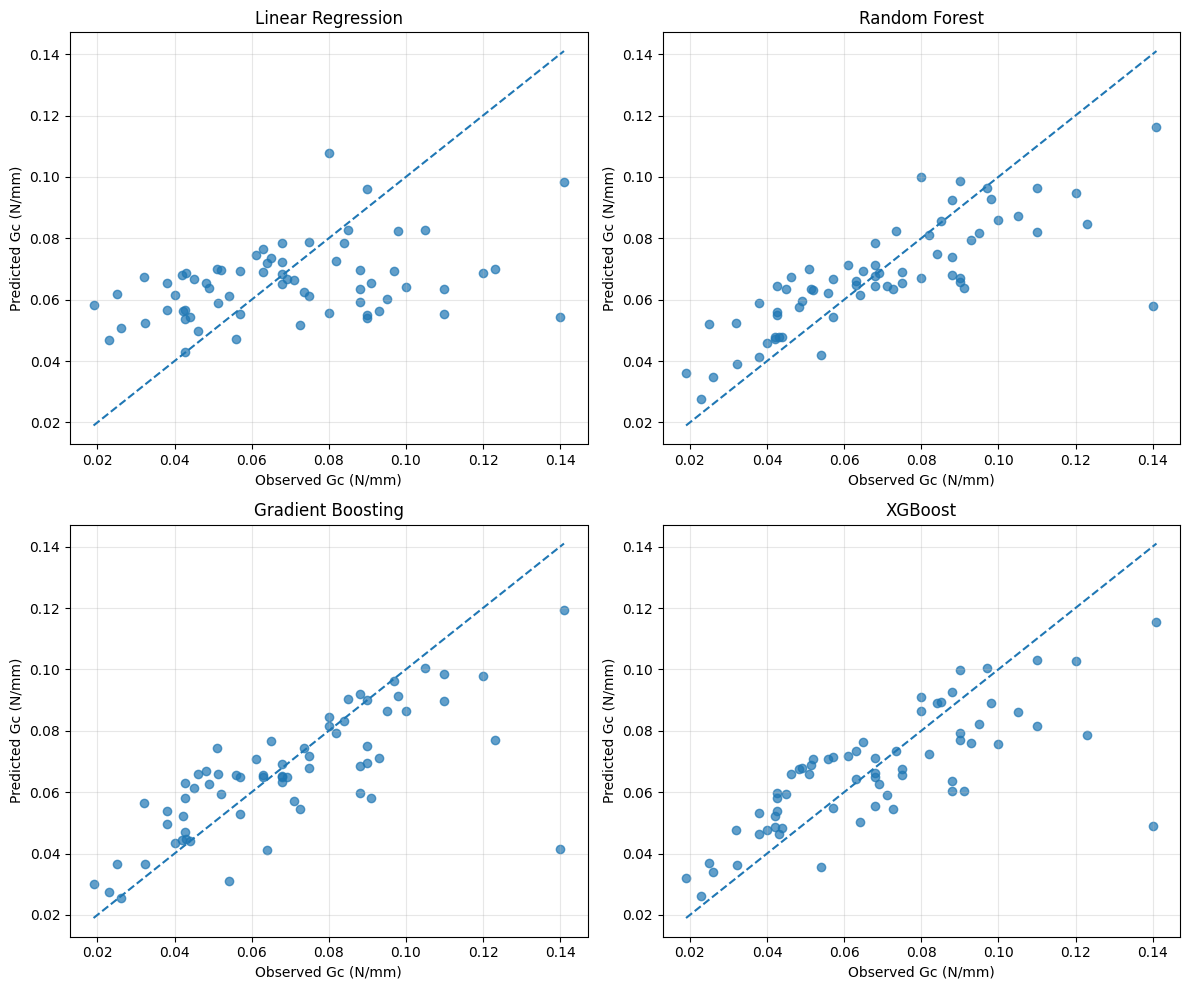

In [32]:
predictions = {
    "Linear Regression": linear_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gb_predictions,
    "XGBoost": xgb_predictions
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, predictions_model) in zip(
    axes.flatten(),
    predictions.items()
):
    ax.scatter(
        y_test,
        predictions_model,
        alpha=0.7
    )

    min_value = min(y_test.min(), predictions_model.min())
    max_value = max(y_test.max(), predictions_model.max())

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    ax.set_xlabel("Observed Gc (N/mm)")
    ax.set_ylabel("Predicted Gc (N/mm)")
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 10.3 Feature Importance

Feature importance analysis was used to examine the relative contribution of the predictor variables to the nonlinear regression models. This analysis provides insight into which geometric and material properties were most influential in predicting fracture energy (`Gc`). Feature importance was examined for the Random Forest, Gradient Boosting, and XGBoost models.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": predictor_columns,
    "Random Forest": rf_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_,
    "XGBoost": xgb_model.feature_importances_
})

feature_importance

,Feature,Random Forest,Gradient Boosting,XGBoost
0,d (mm),0.136178,0.125462,0.152734
1,S (mm),0.093539,0.110137,0.131729
2,bw (mm),0.135109,0.172279,0.252971
3,a0 (mm),0.161598,0.123643,0.116181
4,ft (MPa),0.321375,0.320758,0.189699
5,E (GPa),0.152201,0.147721,0.156685


### 10.4 Feature Importance Comparison

The feature importance values were visualized to facilitate comparison of the relative contribution assigned to each predictor by the three nonlinear regression models.

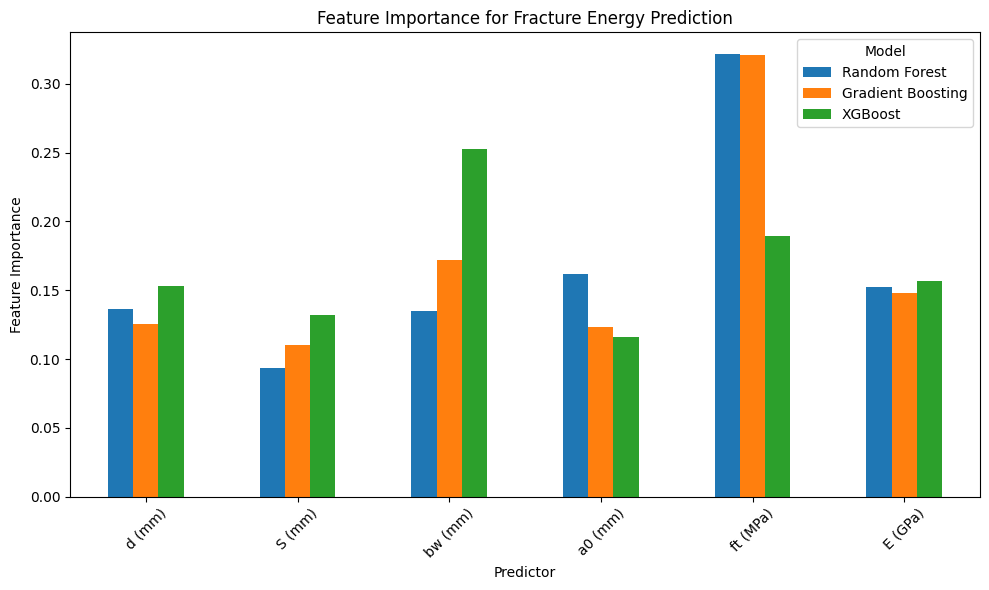

In [34]:
feature_importance_plot = feature_importance.set_index("Feature")

ax = feature_importance_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Predictor")
ax.set_ylabel("Feature Importance")
ax.set_title("Feature Importance for Fracture Energy Prediction")
ax.legend(title="Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10.5 Residual Analysis

Residual analysis was conducted to examine the magnitude and distribution of prediction errors for the four regression models. The residual was calculated as the difference between the observed and predicted fracture energy values. Residual plots were used to identify systematic patterns, changes in error magnitude, and observations with relatively large prediction errors.

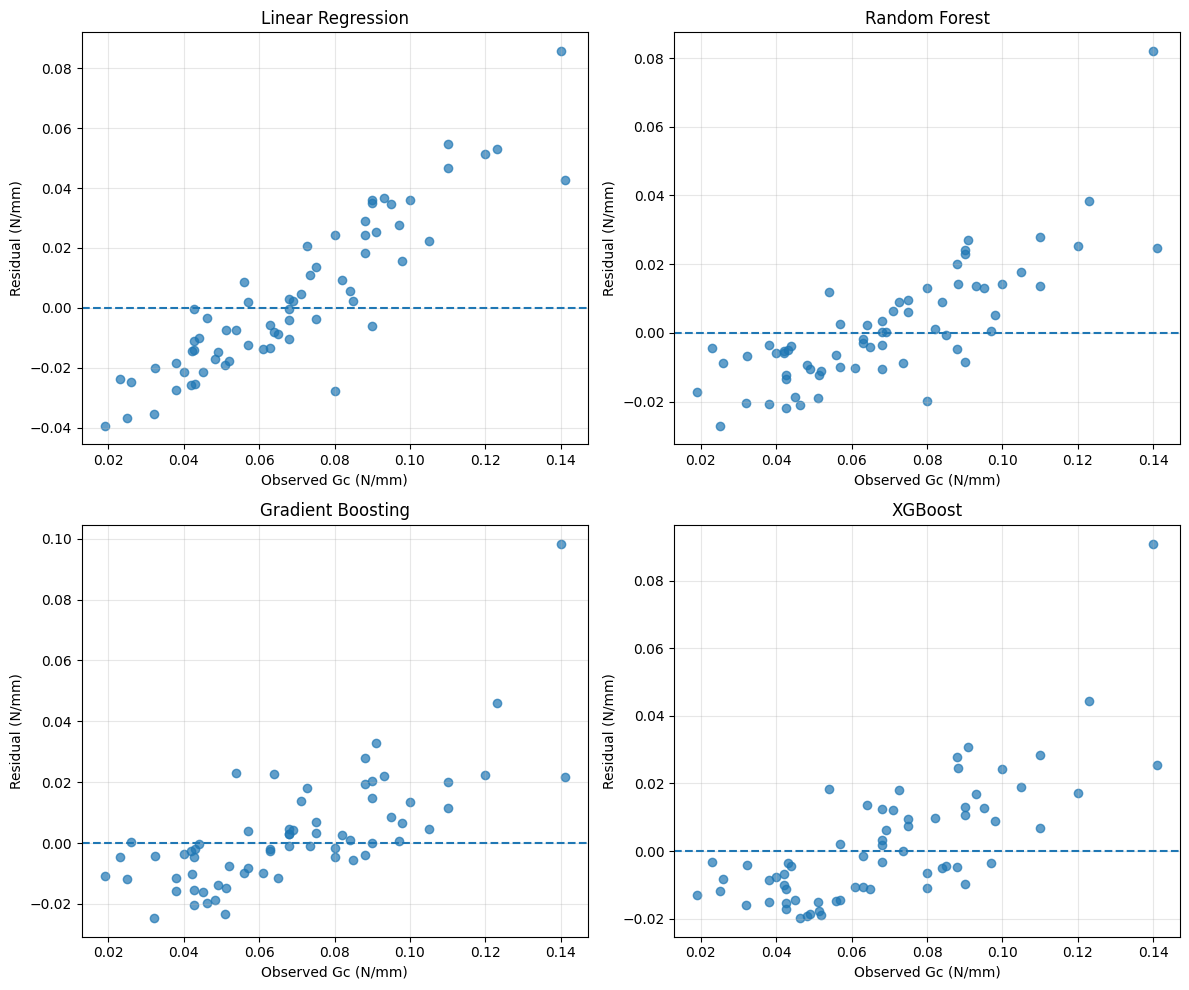

In [35]:
residuals = {
    "Linear Regression": y_test - linear_predictions,
    "Random Forest": y_test - rf_predictions,
    "Gradient Boosting": y_test - gb_predictions,
    "XGBoost": y_test - xgb_predictions
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, residual) in zip(
    axes.flatten(),
    residuals.items()
):
    ax.scatter(
        y_test,
        residual,
        alpha=0.7
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    ax.set_xlabel("Observed Gc (N/mm)")
    ax.set_ylabel("Residual (N/mm)")
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 10.6 Prediction Error Distribution

The distribution of absolute prediction errors was examined to compare the magnitude of errors produced by the four regression models. Absolute error was calculated as the absolute difference between the observed and predicted fracture energy values.

/tmp/ipykernel_4857/2512075962.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


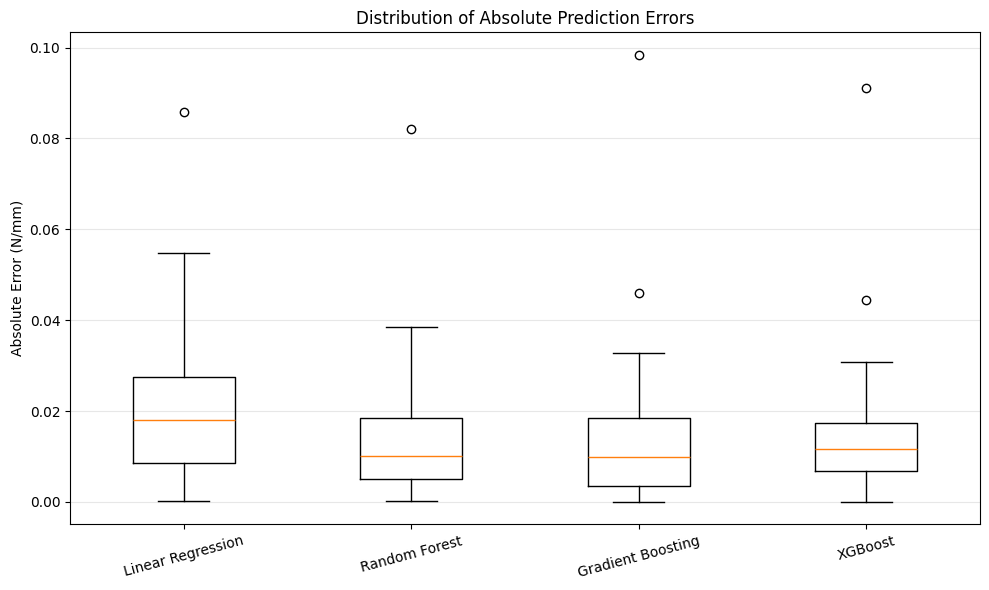

In [36]:
absolute_errors = {
    "Linear Regression": np.abs(y_test - linear_predictions),
    "Random Forest": np.abs(y_test - rf_predictions),
    "Gradient Boosting": np.abs(y_test - gb_predictions),
    "XGBoost": np.abs(y_test - xgb_predictions)
}

error_df = pd.DataFrame(absolute_errors)

plt.figure(figsize=(10, 6))

plt.boxplot(
    error_df.values,
    labels=error_df.columns
)

plt.ylabel("Absolute Error (N/mm)")
plt.title("Distribution of Absolute Prediction Errors")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save Fracture Analysis Results

This section saves the model performance results, feature importance values, and test-set predictions generated during the fracture-energy analysis. The saved outputs provide reproducible records of the machine-learning results for subsequent interpretation and reporting.

In [40]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path("/content/concrete-crack-and-fracture-analysis-repo")

RESULTS_TABLES = REPO_ROOT / "results" / "tables"
RESULTS_METRICS = REPO_ROOT / "results" / "metrics"

RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_METRICS.mkdir(parents=True, exist_ok=True)

model_results.to_csv(
    RESULTS_METRICS / "fracture_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    RESULTS_METRICS / "fracture_feature_importance.csv",
    index=False
)

error_df.to_csv(
    RESULTS_METRICS / "fracture_absolute_errors.csv",
    index=False
)

test_predictions = pd.DataFrame({
    "Observed_Gc": y_test.values,
    "Linear_Regression": linear_predictions,
    "Random_Forest": rf_predictions,
    "Gradient_Boosting": gb_predictions,
    "XGBoost": xgb_predictions
})

test_predictions["Linear_Regression_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["Linear_Regression"]
)

test_predictions["Random_Forest_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["Random_Forest"]
)

test_predictions["Gradient_Boosting_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["Gradient_Boosting"]
)

test_predictions["XGBoost_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["XGBoost"]
)

test_predictions.to_csv(
    RESULTS_METRICS / "fracture_test_predictions_residuals.csv",
    index=False
)

cv_results = model_results[
    [
        "Model",
        "CV_R2",
        "CV_RMSE",
        "CV_MAE"
    ]
].copy()

cv_results.to_csv(
    RESULTS_METRICS / "fracture_cross_validation_results.csv",
    index=False
)

print("Saved fracture analysis results to:")
print(RESULTS_METRICS)

Saved fracture analysis results to:
/content/concrete-crack-and-fracture-analysis-repo/results/metrics


In [41]:
!find /content -type d -name ".git" -print

/content/concrete-crack-and-fracture-analysis-repo/.git


### 11.2 Save Test Predictions and Residuals

The observed fracture-energy values, model predictions, and residuals from the independent test set were saved for reproducibility and subsequent analysis.

In [42]:
test_predictions = pd.DataFrame({
    "Observed_Gc": y_test.values,
    "Linear_Regression": linear_predictions,
    "Random_Forest": rf_predictions,
    "Gradient_Boosting": gb_predictions,
    "XGBoost": xgb_predictions
})

test_predictions["Linear_Regression_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["Linear_Regression"]
)

test_predictions["Random_Forest_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["Random_Forest"]
)

test_predictions["Gradient_Boosting_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["Gradient_Boosting"]
)

test_predictions["XGBoost_Residual"] = (
    test_predictions["Observed_Gc"]
    - test_predictions["XGBoost"]
)

test_predictions.to_csv(
    RESULTS_METRICS / "fracture_test_predictions_residuals.csv",
    index=False
)

print("Saved test predictions and residuals.")
print("Rows:", len(test_predictions))

Saved test predictions and residuals.
Rows: 66


In [43]:
test_predictions.to_csv(
    RESULTS_METRICS / "fracture_test_predictions_residuals.csv",
    index=False
)

cv_results.to_csv(
    RESULTS_METRICS / "fracture_cross_validation_results.csv",
    index=False
)

print("Saved test predictions, residuals, and cross-validation results.")

Saved test predictions, residuals, and cross-validation results.


### 11.3 Save Cross-Validation Results

The five-fold cross-validation results were saved separately from the independent test-set results. This provides a record of model performance across multiple validation folds within the training data.

In [44]:
cv_results = model_results[
    [
        "Model",
        "CV_R2",
        "CV_RMSE",
        "CV_MAE"
    ]
].copy()

cv_results.to_csv(
    RESULTS_METRICS / "fracture_cross_validation_results.csv",
    index=False
)

cv_results

,Model,CV_R2,CV_RMSE,CV_MAE
0,Linear Regression,0.077094,0.026147,0.021004
1,Random Forest,0.438277,0.020436,0.014666
2,Gradient Boosting,0.380205,0.021482,0.015757
3,XGBoost,0.425616,0.020702,0.015492


### 11.4 Final Output Check

The saved outputs were checked to confirm that the principal results from the fracture-energy analysis were successfully generated and stored in the project results directories.

In [45]:
saved_files = [
    RESULTS_METRICS / "fracture_model_comparison.csv",
    RESULTS_METRICS / "fracture_feature_importance.csv",
    RESULTS_METRICS / "fracture_absolute_errors.csv",
    RESULTS_METRICS / "fracture_test_predictions_residuals.csv",
    RESULTS_METRICS / "fracture_cross_validation_results.csv"
]

for file_path in saved_files:
    print(
        f"{file_path.name}:",
        "Saved" if file_path.exists() else "Missing"
    )

fracture_model_comparison.csv: Saved
fracture_feature_importance.csv: Saved
fracture_absolute_errors.csv: Saved
fracture_test_predictions_residuals.csv: Saved
fracture_cross_validation_results.csv: Saved
